In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
%matplotlib inline
df = pd.read_csv("C:\\Users\\Zenith Joshua\\Desktop\\intern 2\\adult 3.csv")
df.head(10)

Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,?,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


In [3]:
df.shape

(48842, 15)

In [4]:
df['income'].unique()

array(['<=50K', '>50K'], dtype=object)

In [5]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

<Axes: ylabel='hours-per-week'>

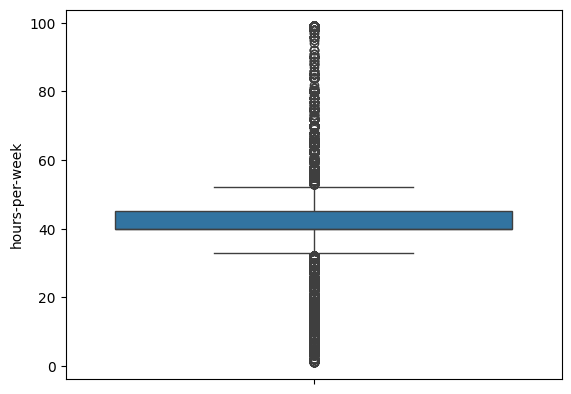

In [6]:
sns.boxplot(df['hours-per-week'])

In [7]:
def remove_outlier_hours_per_week(df):
  IQR = df['hours-per-week'].quantile(0.75) - df['hours-per-week'].quantile(0.25)
  lower_bound = df['hours-per-week'].quantile(0.25) - (IQR * 1.5)
  upper_bound = df['hours-per-week'].quantile(0.75) + (IQR * 1.5)
  df.loc[df['hours-per-week'] <= lower_bound, 'hours-per-week'] = lower_bound
  df.loc[df['hours-per-week'] >= upper_bound, 'hours-per-week'] = upper_bound

In [8]:
remove_outlier_hours_per_week(df)

C:\Users\Zenith Joshua\AppData\Local\Temp\ipykernel_26424\1111341291.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '32.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['hours-per-week'] <= lower_bound, 'hours-per-week'] = lower_bound


<Axes: ylabel='hours-per-week'>

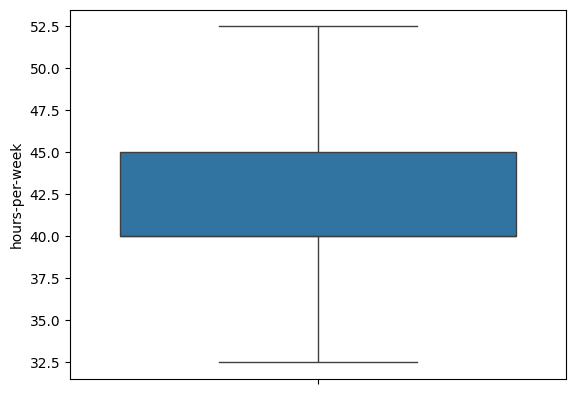

In [9]:
sns.boxplot(df['hours-per-week'])

<Axes: ylabel='educational-num'>

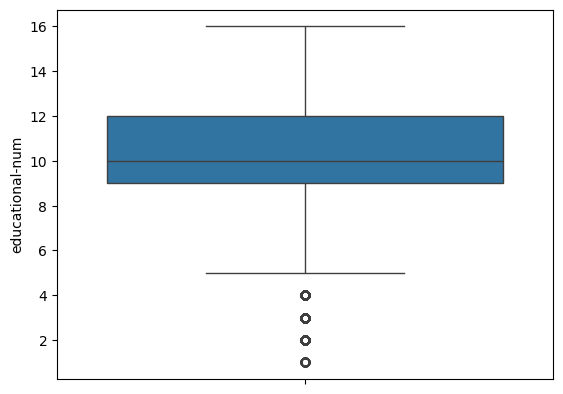

In [10]:
sns.boxplot(df['educational-num'])

<Axes: >

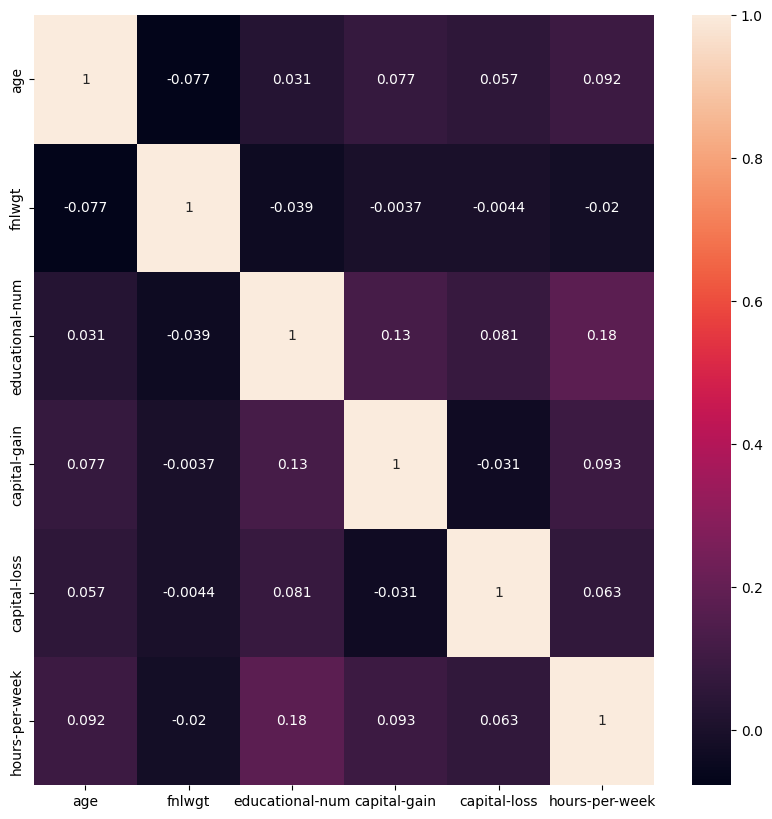

In [11]:
plt.figure(figsize = (10,10))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot = True)

In [12]:
df = df.drop('fnlwgt', axis = 1)

In [13]:
df.head()

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40.0,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50.0,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40.0,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40.0,United-States,>50K
4,18,?,Some-college,10,Never-married,?,Own-child,White,Female,0,0,32.5,United-States,<=50K


In [14]:
def feature_engineering(df):
  df['gender'] = np.where(df['gender'] == ' Male', 1, 0)
  label_enco_race = {value: key for key, value in enumerate(df['race'].unique())}
  df['race'] = df['race'].map(label_enco_race)
  label_enco_relationship = {value: key for key, value in enumerate(df['relationship'].unique())}
  df['relationship'] = df['relationship'].map(label_enco_relationship)
  df['occupation'] = df['occupation'].replace(' ?', df['occupation'].mode()[0])
  label_enco_occupation = {value: key for key, value in enumerate(df['occupation'].unique())}
  df['occupation'] = df['occupation'].map(label_enco_occupation)
  label_enco_martial_status = {value: key for key, value in enumerate(df['marital-status'].unique())}
  df['marital-status'] = df['marital-status'].map(label_enco_martial_status)
  label_enco_education = {value: key for key, value in enumerate(df['education'].unique())}
  df['education'] = df['education'].map(label_enco_education)
  label_enco_workclass = {value: key for key, value in enumerate(df['workclass'].unique())}
  df['workclass'] = df['workclass'].map(label_enco_workclass)
  df['native-country'] = df['native-country'].replace(' ?', df['native-country'].mode()[0])
  label_enco_native_country = {value: key for key, value in enumerate(df['native-country'].unique())}
  df['native-country'] = df['native-country'].map(label_enco_native_country)
  return df

In [15]:
df = feature_engineering(df)

In [16]:
df.head()

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,0,0,7,0,0,0,0,0,0,0,40.0,0,<=50K
1,38,0,1,9,1,1,1,1,0,0,0,50.0,0,<=50K
2,28,1,2,12,1,2,1,1,0,0,0,40.0,0,>50K
3,44,0,3,10,1,0,1,0,0,7688,0,40.0,0,>50K
4,18,2,3,10,0,3,0,1,0,0,0,32.5,0,<=50K


In [17]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [18]:
X = df[['age', 'workclass', 'education', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']]
y = df['income']

In [19]:
y.value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [20]:
X = sc.fit_transform(X)

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [22]:
print("Train data shape: {}".format(X_train.shape))
print("Test data shape: {}".format(X_test.shape))

Train data shape: (39073, 13)
Test data shape: (9769, 13)


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
lg_model = LogisticRegression()
lg_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [24]:
y_pred = lg_model.predict(X_test)

In [25]:
result = {
    'Actual' : y_test,
    'Predicted' : y_pred
}

In [26]:
pd.DataFrame(result)

,Actual,Predicted
7762,<=50K,<=50K
23881,<=50K,<=50K
30507,>50K,>50K
28911,<=50K,<=50K
19484,<=50K,<=50K
...,...,...
43046,>50K,>50K
18798,>50K,>50K
29519,>50K,<=50K
550,<=50K,<=50K


In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy_score(y_test, y_pred)

0.8242399426758112

In [28]:
print("accuracy score: {}".format(accuracy_score(y_test, y_pred)), "\n")
print("confusion matrix: \n {}".format(confusion_matrix(y_test, y_pred)), "\n")
print("classification report: \n {}".format(classification_report(y_test, y_pred)))

accuracy score: 0.8242399426758112 

confusion matrix: 
 [[7078  401]
 [1316  974]] 

classification report: 
               precision    recall  f1-score   support

       <=50K       0.84      0.95      0.89      7479
        >50K       0.71      0.43      0.53      2290

    accuracy                           0.82      9769
   macro avg       0.78      0.69      0.71      9769
weighted avg       0.81      0.82      0.81      9769



In [32]:
import pickle

# Save the trained model to 'model.pkl'
with open('model.pkl', 'wb') as f:
	pickle.dump(lg_model, f)

# Load the model from 'model.pkl'
with open('model.pkl', 'rb') as f:
	loaded_model = pickle.load(f)